In [ ]:
import os, gc, json
import librosa
import numpy as np
import pandas as pd
import torch
import random
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    TrainingArguments,
    Trainer
)

sns.set(style="whitegrid")

d:\UOG\Study\Computing\Final\Ser\con.env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("DataFrame/processed_df.csv")
datasets_all = df["dataset"].unique()

print("Datasets detected:", datasets_all)

Datasets detected: ['RAVDESS' 'TESS' 'SAVEE' 'CREMA']


#### Apply augmentation to training dataframe

In [3]:
# ============================================================
# 2. VISUALIZATION HELPERS (emotion-only, cleaner)
# ============================================================

def plot_distribution(df, title):
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x="emotion", palette="tab10")
    plt.title(title, fontsize=14, weight="bold")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [20]:
# ============================================================
# 3. EMOTION-ONLY AUGMENTATION (separated per LODO case)
# ============================================================

import shutil

AUG_BASE = "Data/Augmented"
os.makedirs(AUG_BASE, exist_ok=True)

def init_aug_folder(test_ds):
    """Create a clean augmentation folder for this LODO case."""
    folder = os.path.join(AUG_BASE, test_ds)
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder, exist_ok=True)
    return folder

# ------------------------------------------------------------
# Basic augmentation functions
# ------------------------------------------------------------

def aug_noise(audio):
    noise = np.random.normal(0, 0.005, len(audio))
    return audio + noise

def aug_gain(audio):
    gain = np.random.uniform(0.8, 1.2)
    return audio * gain

def aug_time_stretch(audio):
    if len(audio) < 2:
        return audio
    rate = np.random.uniform(0.9, 1.1)
    return librosa.effects.time_stretch(y=audio, rate=rate)

AUGS = [aug_noise, aug_gain, aug_time_stretch]


# ------------------------------------------------------------
# Augment and balance train_df inside the isolated LODO folder
# ------------------------------------------------------------
def augment_and_balance(train_df, test_ds):

    print(f"\nBalancing emotions (LODO={test_ds})...")

    aug_dir = os.path.join(AUG_BASE, test_ds)
    os.makedirs(aug_dir, exist_ok=True)

    emotion_counts = train_df["emotion"].value_counts()
    max_count = emotion_counts.max()

    print("\nBefore balancing:")
    print(emotion_counts)

    new_rows = []

    for emotion, count in emotion_counts.items():
        needed = max_count - count
        if needed <= 0:
            continue

        print(f"→ {emotion}: generating {needed} aug samples")

        source_rows = train_df[train_df["emotion"] == emotion]

        for _ in tqdm(range(needed)):
            row = source_rows.sample(1).iloc[0]
            audio, sr = librosa.load(str(row["path"]), sr=16000)

            aug_fn = np.random.choice(AUGS)
            audio_aug = aug_fn(audio)

            # save only inside augmentation folder for this LODO
            out_name = f"{emotion}_AUG_{np.random.randint(int(1e9))}.wav"
            out_path = os.path.join(aug_dir, out_name)
            sf.write(out_path, audio_aug, 16000)

            new_rows.append({
                "dataset": row["dataset"],  # original dataset tag
                "path": out_path,
                "emotion": emotion
            })

    df_aug = pd.concat([train_df, pd.DataFrame(new_rows)], ignore_index=True)
    df_aug = df_aug.sample(frac=1, random_state=42).reset_index(drop=True)

    print("\nAfter balancing:")
    print(df_aug["emotion"].value_counts())

    return df_aug

In [21]:
# ============================================================
# 4. LODO CASE: SPLIT → AUGMENT → VISUALIZE
# ============================================================

def run_lodo_case(test_dataset):
    print("\n====================================")
    print(f"LODO CASE — TEST DATASET = {test_dataset}")
    print("====================================")

    # Split
    train_df = df[df["dataset"] != test_dataset].copy()
    test_df  = df[df["dataset"] == test_dataset].copy()

    print(f"Train = {len(train_df)}, Test = {len(test_df)}")

    # Before augmentation
    plot_emotion_distribution(train_df, f"Before Augmentation — Train (LODO={test_dataset})")

    # Augment
    train_balanced = balance_by_emotion_augmentation(train_df)

    # After augmentation
    plot_emotion_distribution(train_balanced, f"After Augmentation — Balanced Train (LODO={test_dataset})")

    return train_balanced, test_df


In [ ]:
# ============================================================
# 5. TRAINING FUNCTION (Wav2Vec2 for LODO)
# ============================================================

def run_training(train_df, test_df, test_dataset_name):

    print(f"\nTraining Wav2Vec2 — LODO case = {test_dataset_name}")

    # Ensure labels are strings
    train_df["emotion"] = train_df["emotion"].astype(str)
    test_df["emotion"] = test_df["emotion"].astype(str)

    # Split validation
    train_df, val_df = train_test_split(
        train_df,
        test_size=0.1,
        random_state=42,
        stratify=train_df["emotion"]
    )

    # Create global class list
    class_labels = sorted(df["emotion"].astype(str).unique().tolist())
    label2id = {label: i for i, label in enumerate(class_labels)}
    id2label = {i: label for i, label in enumerate(class_labels)}

    # Encode labels
    train_df["label"] = train_df["emotion"].map(label2id)
    val_df["label"] = val_df["emotion"].map(label2id)
    test_df["label"] = test_df["emotion"].map(label2id)

    # Wrap into HF dataset
    def df_to_ds(d):
        d = Dataset.from_pandas(d)
        return d

    hdatasets = DatasetDict({
        "train": df_to_ds(train_df),
        "validation": df_to_ds(val_df),
        "test": df_to_ds(test_df)
    })

    extractor = AutoFeatureExtractor.from_pretrained("facebook/wav2vec2-base")

    def preprocess(batch):
        audio_list = [librosa.load(str(p), sr=16000)[0] for p in batch["path"]]
        inputs = extractor(audio_list, sampling_rate=16000, return_tensors="pt", padding=True)
        inputs["labels"] = batch["label"]
        return inputs

    tokenized = hdatasets.map(
        preprocess,
        remove_columns=hdatasets["train"].column_names,
        batched=True,
        batch_size=4
    )

    for split in tokenized:
        tokenized[split].set_format(
            type="torch",
            columns=["input_values", "labels"]
        )

    # Model
    model = AutoModelForAudioClassification.from_pretrained(
        "facebook/wav2vec2-base",
        num_labels=len(class_labels),
        label2id=label2id,
        id2label=id2label,
        use_safetensors=True,
        ignore_mismatched_sizes=True
    )

    model.gradient_checkpointing_enable()

    out_dir = f"Models/LODO_{test_dataset_name}"
    os.makedirs(out_dir, exist_ok=True)

    args = TrainingArguments(
        output_dir=out_dir,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=3e-5,
        num_train_epochs=10,
        fp16=torch.cuda.is_available(),
        gradient_checkpointing=True
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        processing_class=extractor 
    )

    trainer.train()

    trainer.save_model(os.path.join(out_dir, "final_model"))

    return out_dir


In [ ]:
# ============================================================
# 6. EVALUATION (Confusion Matrix, Metrics, Report)
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

def evaluate_lodo_model(model_dir, test_df, class_labels):

    print(f"\nEvaluating model in: {model_dir}")

    # Load model + feature extractor
    model = AutoModelForAudioClassification.from_pretrained(model_dir + "/final_model")
    extractor = AutoFeatureExtractor.from_pretrained(model_dir + "/final_model")

    # GPU / CPU
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device).eval()

    y_true, y_pred = [], []
    batch_size = 8

    # Loop test samples
    for i in range(0, len(test_df), batch_size):
        batch = test_df.iloc[i:i+batch_size]
        audio_list = [librosa.load(path, sr=16000)[0] for path in batch["path"]]
        true_labels = batch["emotion"].tolist()

        # extract features
        inputs = extractor(audio_list, sampling_rate=16000,
                           return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # inference
        with torch.no_grad():
            logits = model(**inputs).logits
            pred_ids = torch.argmax(logits, dim=-1).cpu().numpy()

        pred_labels = [class_labels[i] for i in pred_ids]

        y_true.extend(true_labels)
        y_pred.extend(pred_labels)

    # ---------------- metrics ----------------
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    metrics = {
        "accuracy": float(acc),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1)
    }

    # save metrics
    with open(model_dir + "/metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    # ---------------- confusion matrix ----------------
    cm = confusion_matrix(
        [class_labels.index(x) for x in y_true],
        [class_labels.index(x) for x in y_pred]
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(cm, display_labels=class_labels).plot(
        ax=ax, cmap="Blues", values_format="d", xticks_rotation=45
    )
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig(model_dir + "/confusion_matrix.png", dpi=200)
    plt.show()

    # ---------------- classification report ----------------
    report = classification_report(y_true, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    # Round to 2 decimal places
    report_df = report_df.round(2)
    report_df.to_csv(model_dir + "/classification_report.csv")

    # ---------------- raw predictions ----------------
    pd.DataFrame({"y_true": y_true, "y_pred": y_pred}).to_csv(
        model_dir + "/predictions.csv", index=False
    )

    return metrics




LODO CASE: Testing on RAVDESS

Train = 10722, Test = 2452


C:\Users\helen\AppData\Local\Temp\ipykernel_5636\265179926.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="emotion", palette="tab10")


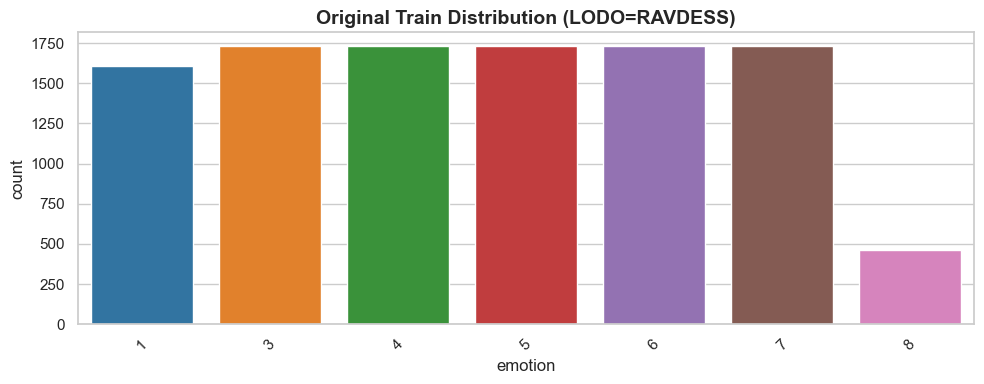


Balancing emotions (LODO=RAVDESS)...

Before balancing:
emotion
3    1731
4    1731
5    1731
7    1731
6    1731
1    1607
8     460
Name: count, dtype: int64
→ 1: generating 124 aug samples


100%|██████████| 124/124 [00:00<00:00, 128.06it/s]


→ 8: generating 1271 aug samples


100%|██████████| 1271/1271 [00:08<00:00, 147.16it/s]
C:\Users\helen\AppData\Local\Temp\ipykernel_5636\265179926.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="emotion", palette="tab10")



After balancing:
emotion
4    1731
3    1731
6    1731
7    1731
5    1731
8    1731
1    1731
Name: count, dtype: int64


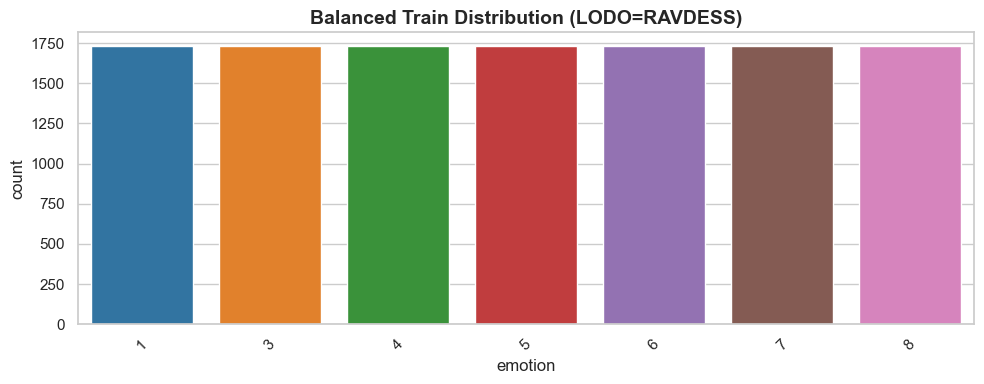


Training Wav2Vec2 — LODO case = RAVDESS


d:\UOG\Study\Computing\Final\Ser\con.env\Lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
Map: 100%|██████████| 2452/2452 [00:02<00:00, 1144.86 examples/s]
Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
d:\UOG\Study\Computing\Final\Ser\con.env\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [30]:
# ========================
# 7. RUN LODO EXPERIMENT 
# ========================

summary_results = []
class_labels = sorted(df["emotion"].astype(str).unique().tolist())

for test_ds in datasets_all:

    print("\n\n===================================================")
    print(f"LODO CASE: Testing on {test_ds}")
    print("===================================================\n")

    # ----------------------------------------------------
    # CLEAN augmentation folder for this LODO case
    # ----------------------------------------------------
    aug_dir = init_aug_folder(test_ds)

    # ----------------------------------------------------
    # 1. SPLIT
    # ----------------------------------------------------
    train_df = df[df["dataset"] != test_ds].copy()
    test_df  = df[df["dataset"] == test_ds].copy()

    print(f"Train = {len(train_df)}, Test = {len(test_df)}")

    plot_distribution(train_df,
        f"Original Train Distribution (LODO={test_ds})")

    # ----------------------------------------------------
    # 2. AUGMENT (safe folder)
    # ----------------------------------------------------
    train_bal = augment_and_balance(train_df, test_ds)

    plot_distribution(train_bal,
        f"Balanced Train Distribution (LODO={test_ds})")

    # ----------------------------------------------------
    # 3. TRAIN
    # ----------------------------------------------------
    model_dir = run_training(train_bal, test_df, test_ds)

    # ----------------------------------------------------
    # 4. EVALUATE
    # ----------------------------------------------------
    metrics = evaluate_lodo_model(model_dir, test_df, class_labels)
    metrics["test_dataset"] = test_ds

    summary_results.append(metrics)

# ------------------------------------------------------------
# SAVE SUMMARY
# ------------------------------------------------------------
summary_df = pd.DataFrame(summary_results)
summary_df.to_csv("Models/LODO_summary.csv", index=False)

print("\nLODO SUMMARY:")
print(summary_df)